## Lagrange interpolation

example
x | f(x)
2 | 4
3 | 9
4 | 16

u(x) = (x - 2) * (x - 3) * (x - 4)

general

x0, .. , xn -> given nodes
f(x0), .. , f(xn) -> given values
f0 = f(x0)

u(x) = (x-x0)(x-x1)..(x-xn)

u_j(x) = u(x) / (x-x_j)

### Lagrange interpolation polynomial classical form

Lnf(x) = sum(f_i * u_i(x) / u_i(x_i)) = 
 = u(x) * sum(f_i * (1/u_i(x_i)/(x-x_i))) => 1/u_i(x_i) is the weight w_i
 = u(x) * sum(f_i * w_i/(x-x_i)) -> Barycentric form

In [3]:
# exercise 1
# f(x) = (x + 1) / 3x^2 + 2x + 1
# a) find the lagrange polynomial L9f(10 nodes) (in classical form) that interpolates f at 10 equally spaced nodes in [-2, 4]
import numpy as np

# f(x) = (x + 1) / (3x^2 + 2x + 1)
def f(x):
    return (x + 1) / (3 * x**2 + 2 * x + 1)

# 10 equally spaced nodes in [-2, 4]
x_nodes = np.linspace(-2, 4, 10)
y_nodes = f(x_nodes)

# Classical Lagrange interpolation polynomial L9 (evaluated numerically)
def L9(x):
    x = np.asarray(x, dtype=float)
    result = np.zeros_like(x, dtype=float)

    for i in range(len(x_nodes)):
        li = np.ones_like(x, dtype=float)
        for j in range(len(x_nodes)):
            if i != j:
                li *= (x - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
        result += y_nodes[i] * li

    return result

# Expanded polynomial coefficients (descending powers):
# L9(x) = c0*x^9 + c1*x^8 + ... + c9
coeffs = np.polyfit(x_nodes, y_nodes, 9)
poly = np.poly1d(coeffs)

print("Nodes x_i:")
print(x_nodes)
print("\nValues f(x_i):")
print(y_nodes)
print("\nExpanded polynomial L9(x):")
print(poly)

# Quick check at interpolation nodes
max_err = np.max(np.abs(poly(x_nodes) - y_nodes))
print(f"\nmax |L9(x_i) - f(x_i)| at nodes = {max_err:.3e}")

Nodes x_i:
[-2.         -1.33333333 -0.66666667  0.          0.66666667  1.33333333
  2.          2.66666667  3.33333333  4.        ]

Values f(x_i):
[-0.11111111 -0.09090909  0.33333333  1.          0.45454545  0.25925926
  0.17647059  0.13253012  0.10569106  0.0877193 ]

Expanded polynomial L9(x):
         9           8         7           6          5          4
0.00379 x - 0.03848 x + 0.106 x + 0.09504 x - 0.7857 x + 0.5848 x
          3         2
 + 1.308 x - 1.639 x - 0.3448 x + 1

max |L9(x_i) - f(x_i)| at nodes = 2.796e-12


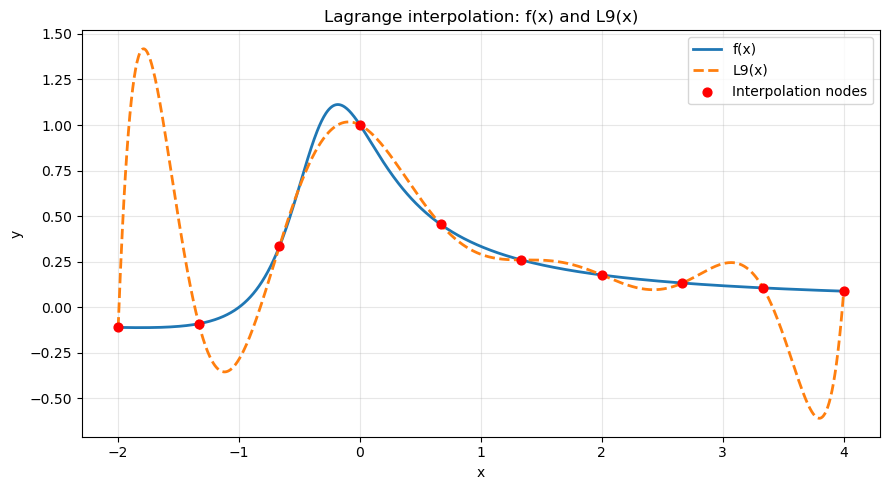

In [5]:
# b) plot the nodes, f and L9f, on the same set of axes.
import matplotlib.pyplot as plt

x_plot = np.linspace(-2, 4, 1000)
y_f = f(x_plot)
y_l9 = L9(x_plot)

plt.figure(figsize=(9, 5))
plt.plot(x_plot, y_f, label="f(x)", linewidth=2)
plt.plot(x_plot, y_l9, "--", label="L9(x)", linewidth=2)
plt.scatter(x_nodes, y_nodes, color="red", s=40, label="Interpolation nodes", zorder=3)
plt.title("Lagrange interpolation: f(x) and L9(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

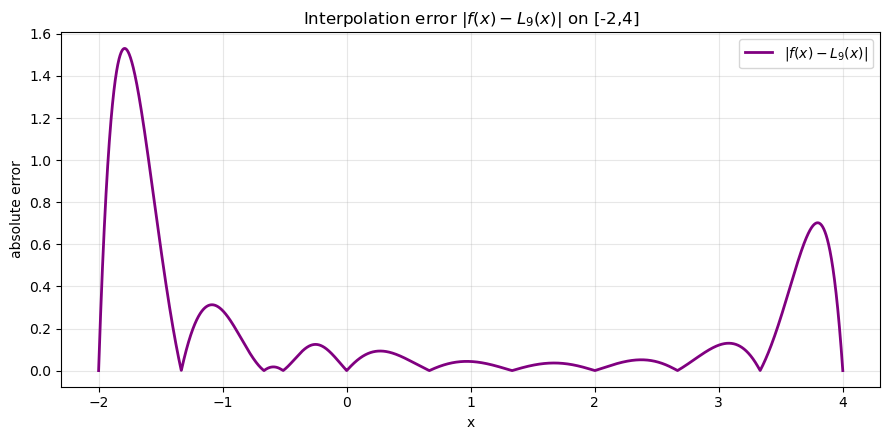

Maximum error on [-2,4] (grid-based): 1.530644e+00
Attained near x = -1.789958


In [6]:
# c) plot the errors |f-L9f| and compute the maximum error on [-2,4]
# (uses f and L9 defined above)

x_err = np.linspace(-2, 4, 5000)
err = np.abs(f(x_err) - L9(x_err))

max_err = np.max(err)
x_at_max = x_err[np.argmax(err)]

plt.figure(figsize=(9, 4.5))
plt.plot(x_err, err, color="purple", linewidth=2, label=r"$|f(x)-L_9(x)|$")
plt.title(r"Interpolation error $|f(x)-L_9(x)|$ on [-2,4]")
plt.xlabel("x")
plt.ylabel("absolute error")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Maximum error on [-2,4] (grid-based): {max_err:.6e}")
print(f"Attained near x = {x_at_max:.6f}")

In [8]:
# d) approximate f(1/2) by L9f(1/2). what is the error of this approximation?
# (uses f and L9 defined above)

x0 = 0.5
f_exact = f(x0)
f_approx = L9(x0)
abs_err = abs(f_exact - f_approx)
rel_err = abs_err / abs(f_exact)

print(f"f(1/2) exact      = {f_exact:.12f}")
print(f"L9(1/2) approx    = {f_approx:.12f}")
print(f"absolute error    = {abs_err:.12f}")
print(f"relative error    = {rel_err:.12f}")

f(1/2) exact      = 0.545454545455
L9(1/2) approx    = 0.595566778202
absolute error    = 0.050112232747
relative error    = 0.091872426703


In [10]:
# exercise 2
'''
According to the National Institute of Statistics, the following data represents Romania’s population
between 1980 and 2020:

Year | Population
1980 | 22.21
1990 | 23.21
2000 | 22.14
2010 | 20.43
2020 | 19.39

Use the Barycentric formula (first markdown cell) to interpolate these data and approximate the populataion of Romania in 2005 and 2015. Knowing the actual population was 21.21 million in 2005 and 19.91 million people in 2015, how good are these approximations (compute the relative errors)?
'''

import numpy as np

# Given data (year, population in millions)
x = np.array([1980.0, 1990.0, 2000.0, 2010.0, 2020.0])
y = np.array([22.21, 23.21, 22.14, 20.43, 19.39])

# Barycentric weights: w_i = 1 / prod_{j!=i}(x_i - x_j)
def barycentric_weights(x_nodes):
    n = len(x_nodes)
    w = np.ones(n, dtype=float)
    for i in range(n):
        prod = 1.0
        for j in range(n):
            if i != j:
                prod *= (x_nodes[i] - x_nodes[j])
        w[i] = 1.0 / prod
    return w

# Barycentric interpolation formula:
# L(x) = [sum(w_i * y_i / (x - x_i))] / [sum(w_i / (x - x_i))]
def barycentric_interpolate(x_eval, x_nodes, y_nodes, w):
    x_eval = np.asarray(x_eval, dtype=float)
    out = np.empty_like(x_eval, dtype=float)

    for k, xv in enumerate(x_eval):
        # If xv is exactly one of the nodes, return the corresponding y value
        idx = np.where(np.isclose(xv, x_nodes))[0]
        if idx.size > 0:
            out[k] = y_nodes[idx[0]]
            continue

        numer = np.sum(w * y_nodes / (xv - x_nodes))
        denom = np.sum(w / (xv - x_nodes))
        out[k] = numer / denom

    return out

w = barycentric_weights(x)

# Approximations requested
years_eval = np.array([2005.0, 2015.0])
approx = barycentric_interpolate(years_eval, x, y, w)

actual_2005 = 21.21
actual_2015 = 19.91
actual = np.array([actual_2005, actual_2015])

abs_err = np.abs(approx - actual)
rel_err = abs_err / np.abs(actual)

print("Barycentric weights w_i:")
print(w)
print()
print(f"Approx population in 2005: {approx[0]:.6f} million")
print(f"Actual  population in 2005: {actual[0]:.6f} million")
print(f"Relative error (2005):      {rel_err[0]:.6} ({100*rel_err[0]:.4f}%)")
print()
print(f"Approx population in 2015: {approx[1]:.6f} million")
print(f"Actual  population in 2015: {actual[1]:.6f} million")
print(f"Relative error (2015):      {rel_err[1]:.6f} ({100*rel_err[1]:.4f}%)")

Barycentric weights w_i:
[ 4.16666667e-06 -1.66666667e-05  2.50000000e-05 -1.66666667e-05
  4.16666667e-06]

Approx population in 2005: 21.280313 million
Actual  population in 2005: 21.210000 million
Relative error (2005):      0.00331506 (0.3315%)

Approx population in 2015: 19.749062 million
Actual  population in 2015: 19.910000 million
Relative error (2015):      0.008083 (0.8083%)


In [11]:
# exercise 3: use Lagrange interpolation to approximate sqrt(118)

import math

# We interpolate g(x) = sqrt(x) using nearby perfect-square nodes
# so that function values are exact integers:
# (81, 9), (100, 10), (121, 11), (144, 12)
x_nodes = [81.0, 100.0, 121.0, 144.0]
y_nodes = [9.0, 10.0, 11.0, 12.0]

def lagrange_eval(x, x_nodes, y_nodes):
    n = len(x_nodes)
    s = 0.0
    for i in range(n):
        li = 1.0
        for j in range(n):
            if i != j:
                li *= (x - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
        s += y_nodes[i] * li
    return s

x0 = 118.0
sqrt_approx = lagrange_eval(x0, x_nodes, y_nodes)
sqrt_true = math.sqrt(x0)
abs_err = abs(sqrt_true - sqrt_approx)

print(f"Lagrange approximation for sqrt(118): {sqrt_approx:.12f}")
print(f"True value math.sqrt(118):            {sqrt_true:.12f}")
print(f"Absolute error:                       {abs_err:.12e}")
print(f"Approximation to 3 decimals:          {sqrt_approx:.3f}")

if abs_err < 5e-4:
    print("=> 3 correct decimals are guaranteed.")
else:
    print("=> 3 correct decimals are NOT guaranteed.")


Lagrange approximation for sqrt(118): 10.862920146215
True value math.sqrt(118):            10.862780491200
Absolute error:                       1.396550151256e-04
Approximation to 3 decimals:          10.863
=> 3 correct decimals are guaranteed.
